In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approximate haploid genome length (Mb)
GENOME_LENGTH_MB = 2880

PLINK_FILE = "./results/plink_results/full_plink.genome"
GERMLINE_FILE = "./results/germline_results/germline_full_out.match"

In [2]:
# ===============================
# PLINK Loader
# ===============================

def load_plink_results(filepath):

    if not os.path.exists(filepath):
        print("PLINK file not found")
        return pd.DataFrame()

    df = pd.read_csv(filepath, delim_whitespace=True)

    # PLINK genome files usually contain:
    # FID1 IID1 FID2 IID2 PI_HAT ...

    required_cols = ["IID1", "IID2", "PI_HAT"]

    # Try flexible column detection
    if "IID1" not in df.columns:
        # assume PLINK format with FID IID pairs
        df["IID1"] = df.iloc[:, 1].astype(str)
        df["IID2"] = df.iloc[:, 3].astype(str)
        df["PI_HAT"] = pd.to_numeric(df.iloc[:, 6], errors="coerce")

    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([r["IID1"], r["IID2"]])),
        axis=1
    )

    return df[["pair_id", "IID1", "IID2", "PI_HAT"]]

In [3]:
# ===============================
# GERMLINE Loader
# ===============================

def load_germline_results(filepath):

    if not os.path.exists(filepath) or os.path.getsize(filepath) == 0:
        print("GERMLINE output empty")
        return pd.DataFrame()

    df = pd.read_csv(
        filepath,
        sep=r"\s+",
        header=None,
        engine="python"
    )

    print("GERMLINE detected columns:", df.shape[1])

    # GERMLINE format assumption:
    # 0 IID1_FID
    # 1 IID1_IID
    # 2 IID2_FID
    # 3 IID2_IID
    # 4 chromosome
    # 5 start_bp
    # 6 end_bp
    # 7 SNP_start
    # 8 SNP_end
    # 9 segment_snps
    # 10 segment_length
    # 11 unit (MB or cM)

    if df.shape[1] < 11:
        print("Unexpected GERMLINE format")
        return pd.DataFrame()

    df["IID1"] = df.iloc[:, 1].astype(str)
    df["IID2"] = df.iloc[:, 3].astype(str)
    start = pd.to_numeric(df.iloc[:, 5], errors="coerce")
    end = pd.to_numeric(df.iloc[:, 6], errors="coerce")
    chr = pd.to_numeric(df.iloc[:, 4], errors="coerce")

    # Extract segment length safely
    length = pd.to_numeric(df.iloc[:, 10], errors="coerce")

    out = pd.DataFrame({
        "IID1": df["IID1"],
        "IID2": df["IID2"],
        "start": start,
        "end": end,
        "length": length,
        "chr": chr
    })
    print("out:\n")
    print(out)

    return out

In [11]:
# ===============================
# GERMLINE Relatedness Score
# ===============================

def compute_germline_relatedness(df):

    if df.empty:
        return pd.DataFrame(columns=["pair_id", "GERMLINE_score"])

    # Construct standardized pair ID
    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([str(r["IID1"]), str(r["IID2"])])),
        axis=1
    )

    # Convert genomic coordinates safely
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["end"] = pd.to_numeric(df["end"], errors="coerce")
    df = df.dropna(subset=["start", "end"])

    # Group by pair + chromosome (VERY IMPORTANT ⭐)
    grouped = df.groupby(["pair_id", "chr"])

    def merge_intervals(group):

        group = group.sort_values("start")

        merged_length = 0

        curr_start = group.iloc[0]["start"]
        curr_end = group.iloc[0]["end"]

        for _, row in group.iloc[1:].iterrows():

            if row["start"] <= curr_end:
                curr_end = max(curr_end, row["end"])
            else:
                merged_length += curr_end - curr_start
                curr_start = row["start"]
                curr_end = row["end"]

        merged_length += curr_end - curr_start

        # Convert bp → Mb
        return merged_length / 1e6

    # Apply merging
    merged_records = grouped.apply(
        merge_intervals
    ).reset_index(name="merged_mb")

    # Sum across chromosomes
    pair_lengths = merged_records.groupby("pair_id")[
        "merged_mb"
    ].sum().reset_index()

    # Normalize relatedness score
    GENOME_LENGTH_CM = 2880

    pair_lengths["GERMLINE_score"] = (
        pair_lengths["merged_mb"] / GENOME_LENGTH_CM
    )

    print("pair lengths normalized\n")
    print(pair_lengths)
    print(pair_lengths.sort_values("merged_mb", ascending=False).head(10))

    return pair_lengths[["pair_id", "GERMLINE_score"]]



# ===============================
# Merge Results
# ===============================

def merge_results(plink_df, germline_df):

    print("PLINK pairs example:")
    print(plink_df["pair_id"].head())

    print("\nGERMLINE pairs example:")
    print(germline_df["pair_id"].head())

    merged = pd.merge(
        plink_df,
        germline_df,
        on="pair_id",
        how="inner"
    )

    return merged

In [12]:
# ===============================
# Analysis
# ===============================

def analyze_results(merged_df):

    print("\n===== Summary Statistics =====")

    if merged_df.empty or len(merged_df) < 2:
        print("Not enough data points for correlation analysis.")
        print(f"Matched pairs = {len(merged_df)}")
        return

    print("\nPLINK PI_HAT:")
    print(merged_df["PI_HAT"].describe())

    print("\nGERMLINE Score:")
    print(merged_df["GERMLINE_score"].describe())

    try:
        corr, pval = pearsonr(
            merged_df["PI_HAT"],
            merged_df["GERMLINE_score"]
        )

        print("\n===== Correlation Analysis =====")
        print(f"Pearson correlation = {corr:.4f}")
        print(f"p-value = {pval:.4e}")

    except Exception:
        print("Correlation computation failed")

# ===============================
# Plotting
# ===============================

def plot_scatter(merged_df):

    plt.figure(figsize=(8,6))

    plt.scatter(
        merged_df["PI_HAT"],
        merged_df["GERMLINE_score"],
        alpha=0.6
    )

    # Identity reference line
    plt.plot([0,1],[0,1], linestyle="--")

    plt.xlabel("PLINK PI_HAT")
    plt.ylabel("GERMLINE Relatedness Score")
    plt.title("PLINK vs GERMLINE Relatedness Comparison")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Loading PLINK results...
Loading GERMLINE results...


/var/folders/3y/bbbdm0cd2hdflll1w_k3ddnc0000gn/T/ipykernel_4832/2068880601.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True)


GERMLINE detected columns: 15
out:

          IID1     IID2      start        end   length  chr
0      NA19434  NA19444   22622513   43546204   20.924    1
1      NA19443  NA19470   14014472   48359634   34.345    1
2      NA19396  NA19397   19095101   75275272   56.180    1
3      NA19434  NA19444   76865258   83567501    6.702    1
4      NA19373  NA19374   54869816  111466053   56.596    1
...        ...      ...        ...        ...      ...  ...
65198  NA19321  NA19381  141066491  141066491  141.066    9
65199  NA19036  NA19360  141066491  141066491  141.066    9
65200  NA19373  NA19374  141066491  141066491  141.066    9
65201  NA19380  NA19440  141066491  141066491  141.066    9
65202  NA19397  NA19431  141066491  141066491  141.066    9

[65203 rows x 6 columns]
pair lengths normalized

              pair_id  merged_mb  GERMLINE_score
0     NA19020_NA19028        0.0             0.0
1     NA19020_NA19035        0.0             0.0
2     NA19020_NA19036        0.0             0

/var/folders/3y/bbbdm0cd2hdflll1w_k3ddnc0000gn/T/ipykernel_4832/1114291265.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_records = grouped.apply(


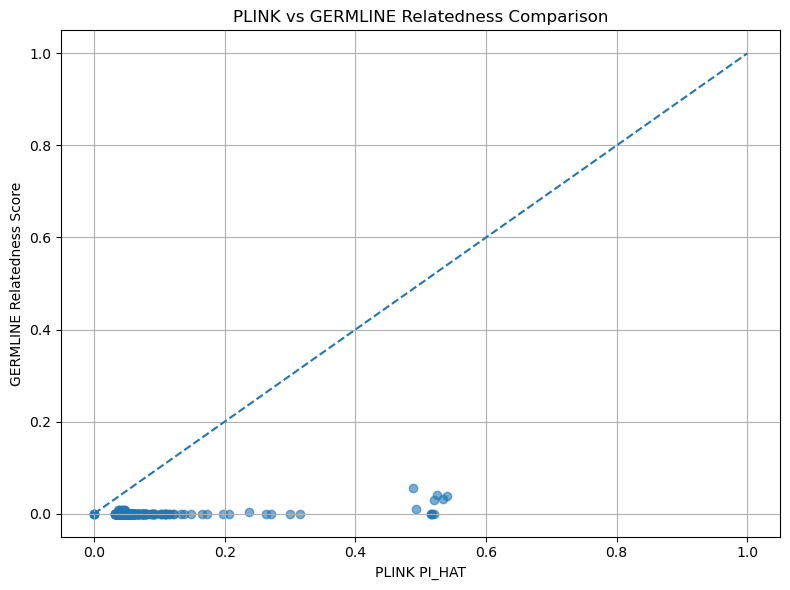

In [15]:
print("Loading PLINK results...")
plink_df = load_plink_results(PLINK_FILE)

print("Loading GERMLINE results...")
germline_raw = load_germline_results(GERMLINE_FILE)

germline_df = compute_germline_relatedness(germline_raw)

print("Merging datasets...")
merged_df = merge_results(plink_df, germline_df)

print(f"\nMatched pairs = {len(merged_df)}")

analyze_results(merged_df)

plot_scatter(merged_df)



In [16]:
print("PLINK output columns:")
print(plink_df.columns)

print("\nSample PLINK rows:")
print(plink_df.head())

print("\nPI_HAT summary:")
print(plink_df["PI_HAT"].describe())

PLINK output columns:
Index(['pair_id', 'IID1', 'IID2', 'PI_HAT'], dtype='object')

Sample PLINK rows:
           pair_id     IID1     IID2  PI_HAT
0  NA19020_NA19028  NA19020  NA19028  0.0419
1  NA19020_NA19035  NA19020  NA19035  0.0400
2  NA19020_NA19036  NA19020  NA19036  0.0435
3  NA19020_NA19038  NA19020  NA19038  0.0401
4  NA19020_NA19041  NA19020  NA19041  0.0401

PI_HAT summary:
count    4656.000000
mean        0.045826
std         0.024539
min         0.000000
25%         0.041200
50%         0.043700
75%         0.046700
max         0.540700
Name: PI_HAT, dtype: float64


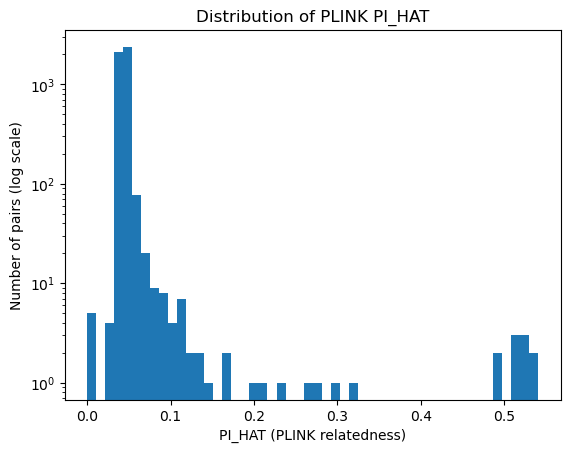

In [ ]:
plt.figure()

plt.hist(plink_df["PI_HAT"], bins=50)

plt.yscale("log") # NOTE THAT WE USE LOG SCALE SO THAT WE CAN STILL SEE SMALLER Y VALUES SHOW UP ON THE GRAPH

plt.xlabel("PI_HAT (PLINK relatedness)")
plt.ylabel("Number of pairs (log scale)")
plt.title("Distribution of PLINK PI_HAT")

plt.show()

In [26]:
print("GERMLINE segment examples:")
print(germline_df.head())

print("\nTotal segments detected:")
print(len(germline_df))

GERMLINE segment examples:
           pair_id  GERMLINE_score
0  NA19020_NA19028             0.0
1  NA19020_NA19035             0.0
2  NA19020_NA19036             0.0
3  NA19020_NA19038             0.0
4  NA19020_NA19041             0.0

Total segments detected:
4656


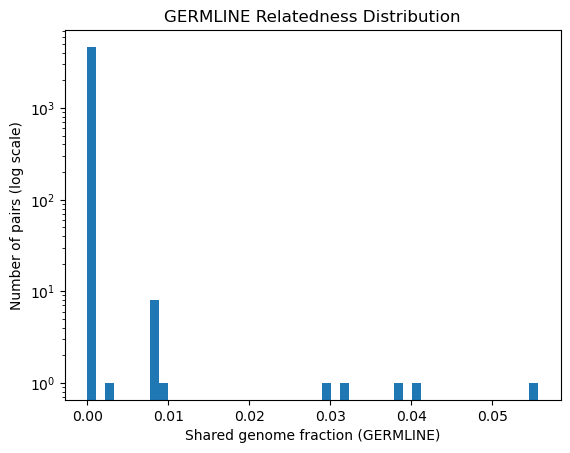

In [ ]:
plt.figure()

plt.hist(germline_df["GERMLINE_score"], bins=50)

plt.yscale("log") # NOTE THAT WE USE LOG SCALE SO THAT WE CAN STILL SEE SMALLER Y VALUES SHOW UP ON THE GRAPH

plt.xlabel("Shared genome fraction (GERMLINE)")
plt.ylabel("Number of pairs (log scale)")
plt.title("GERMLINE Relatedness Distribution")

plt.show()

In [22]:
plink_related = (merged_df["PI_HAT"] > 0.1).sum()
germline_related = (merged_df["GERMLINE_score"] > 0).sum()

print("Pairs detected by PLINK:", plink_related)
print("Pairs detected by GERMLINE:", germline_related)

Pairs detected by PLINK: 35
Pairs detected by GERMLINE: 15


We see a discrepancy in the number of pairs detected by PLINK and GERMLINE due to how they fundamentally calculate relative finding. PLINK compares allele frequencies across SNPs and estimates how many alleles two people share. From this, it computes PI_HAT, which is an appromixation for the proportion of the genome shared IBD. Because this approach relies on statistics and approximation, it is very possible to detect weaker signals of relatedness and will likely find more pairs. In contrast, GERMLINE searches for continuous slices of DNA that match. From our data generation, we required 3 cM of DNA to be identical in order to count it as a match. Therefore, distant relatives and random chance findings are less likely to be included in the final pairs detected. 

In [23]:
def relationship_category(pi):
    if pi > 0.45:
        return "1st degree"
    elif pi > 0.2:
        return "2nd degree"
    elif pi > 0.1:
        return "3rd degree"
    else:
        return "unrelated"

merged_df["relationship"] = merged_df["PI_HAT"].apply(relationship_category)

print(merged_df["relationship"].value_counts())

relationship
unrelated     4621
3rd degree      19
1st degree      10
2nd degree       6
Name: count, dtype: int64


A vast majority of the dataset are not closely related, which is to be expected. First-degree relatives share approximately 50% of their genome. Some examples include parent-child relationships and full sibling relationships. PI_HAT must be roughly 0.5 and the shared distance roughly 1400 Mb. We see that our python notebook detected 10 pairs that meet these metrics. Second-degree relatives share close to 25% of their genome, like grandchild-grandparents and half siblings. Third-degree relatives share about 12.5%  of their genome. Due to the fact that these relationships consist of shorter IBD segments, PLINK can detect them but GERMLINE can potentially miss finding some if their segments are too short. 